# **1. Classification of natural disaster Tweets: EDA**

## Statement
The dataset used in this project comes from the Disaster Tweets dataset, which contains a collection of tweets labeled according to whether they refer to a real disaster event or not. The goal of the dataset is to support the development of machine learning models capable of automatically identifying disaster-related information from social media posts.

https://www.kaggle.com/vstepanenko/disaster-tweets

## 0. Imports

In [8]:
import matplotlib.pyplot as plt
plt.style.use('ggplot') # to change the style
import numpy as np
import os

In [7]:
import pandas as pd
import string
import re

## **1. Reading the data set**

In [65]:
X_train = pd.read_csv('train.csv')


## **2. Visualization of the data set**

The dataset contains **7,613** elements in the training set and **3,263** elements in the testing set, obtained from Kaggle.

In [66]:
print("Size of the training data set: ", len(X_train))

Size of the training data set:  7613


In [67]:
# Tweets of each type found in the training dataset.
X_train['target'].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

In [68]:
print("Percentage of tweets of each type found in the training dataset: ")
X_train['target'].value_counts()/100


Percentage of tweets of each type found in the training dataset: 


target
0    43.42
1    32.71
Name: count, dtype: float64

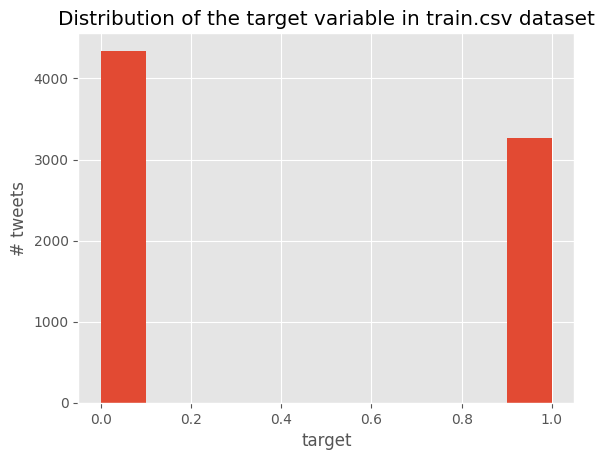

In [69]:
X_train['target'].hist()
plt.ylabel("# tweets")
plt.xlabel("target")
plt.title("Distribution of the target variable in train.csv dataset")
plt.show()

The distribution of the target variable in the training dataset shows a slightly imbalanced binary classification problem. Although the dataset presents a moderate imbalance, both classes remain well represented for training machine learning models.

#### 2.1 **Number of words per Tweet**

Firs we need to calculate the number of words of every class

In [70]:
tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.split().map(lambda x: len(x))
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.split().map(lambda x: len(x))

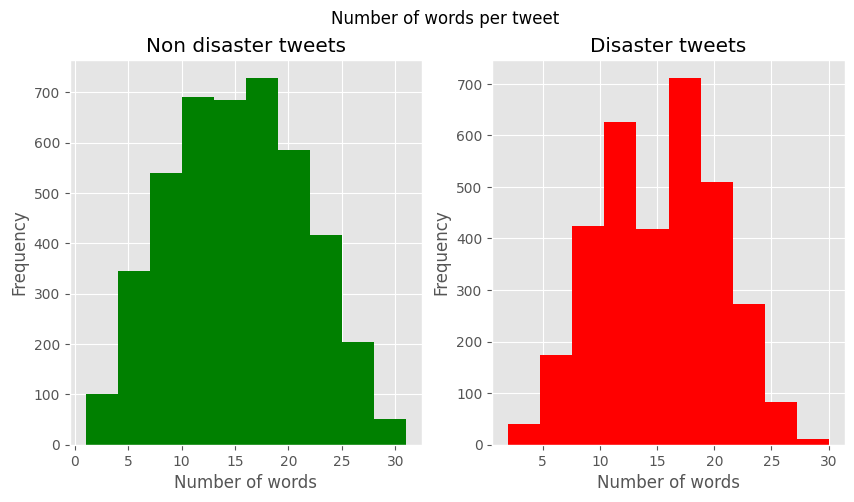

In [71]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')
ax1.set_xlabel('Number of words')
ax1.set_ylabel('Frequency')
ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')
ax2.set_xlabel('Number of words')
ax2.set_ylabel('Frequency')
fig.suptitle('Number of words per tweet')

plt.show()

Both categories show a relatively similar distribution of tweet lengths. Most tweets contain between 10 and 20 words, indicating that typical tweet messages in the dataset fall within this range.

#### 2.2 **Number of unique words per Tweet**

To calculate the length of the tweets in terms of the number of unique words, we can use the following code:

In [72]:
tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.split().map(lambda x: len(set(x)))
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.split().map(lambda x: len(set(x)))

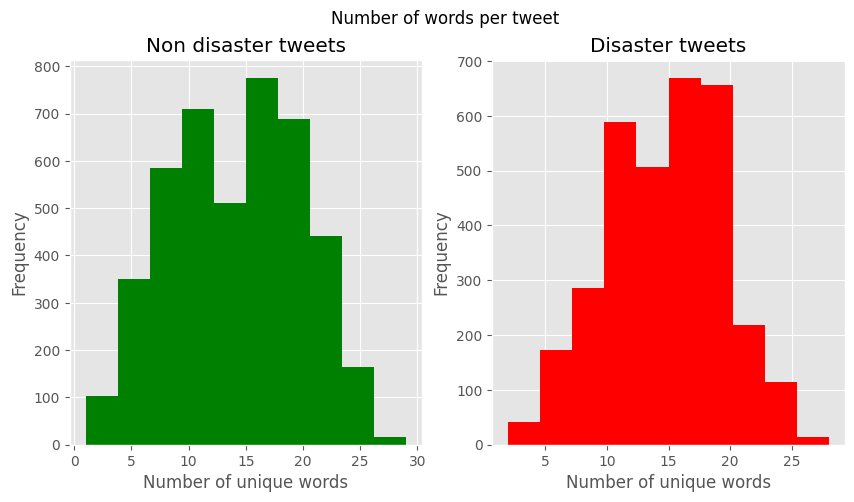

: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')
ax1.set_xlabel('Number of unique words')
ax1.set_ylabel('Frequency')
ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')
ax2.set_xlabel('Number of unique words')
ax2.set_ylabel('Frequency')
fig.suptitle('Number of words per tweet')

plt.show()

### 2.3 **Average word length per Tweet**

In [18]:
def average_length(tweet):
    average = []
    for i in range(len(tweet)):
        average.append(len(tweet[i]))
    return np.mean(average)

tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.split().map(lambda x: average_length(x))
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.split().map(lambda x: average_length(x))

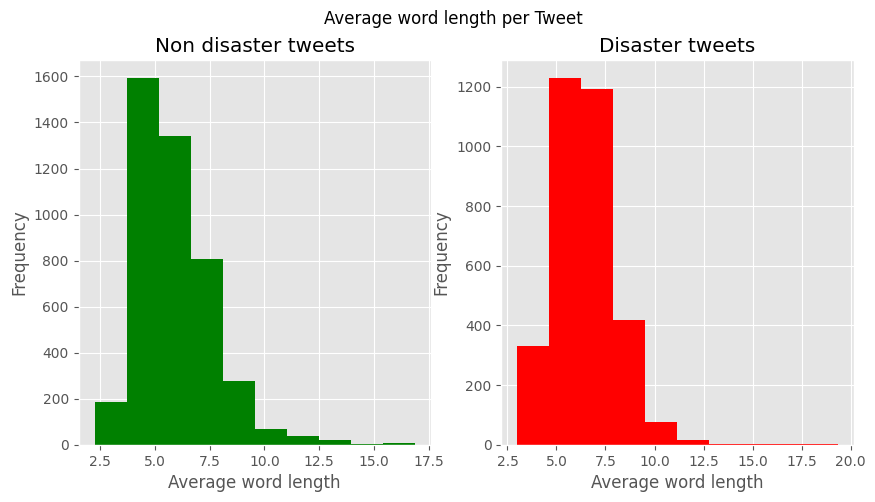

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')
ax1.set_xlabel('Average word length')
ax1.set_ylabel('Frequency')
ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')
ax2.set_xlabel('Average word length')
ax2.set_ylabel('Frequency')

fig.suptitle('Average word length per Tweet')

plt.show()

### 2.4 **Number of characters per tweet**

In [21]:
tweet_len_0 = X_train[X_train['target'] == 0]['text'].str.len()
tweet_len_1 = X_train[X_train['target'] == 1]['text'].str.len()

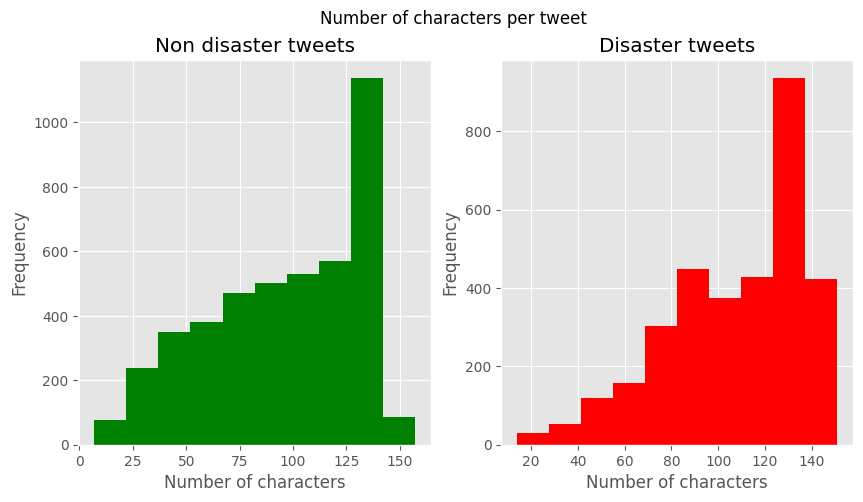

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.hist(tweet_len_0, color='green')
ax1.set_title('Non disaster tweets')
ax1.set_xlabel('Number of characters')
ax1.set_ylabel('Frequency')
ax2.hist(tweet_len_1, color='red')
ax2.set_title('Disaster tweets')
ax2.set_xlabel('Number of characters')
ax2.set_ylabel('Frequency')

fig.suptitle('Number of characters per tweet')

plt.show()

We could continue to calculate input characteristics such as the following:
* Number of end words per Tweet
* Number of urls per Tweet
* Number of punctuation marks per Tweet
* Number of hashtags per Tweet
* Number of @'s per tweet

### **2.5 End words per Tweet**


In [24]:
def end_word(tweet):
    tweet = tweet.split()
    if len(tweet) == 0:
        end_word = ""
    else:
        end_word = tweet[-1]
    return end_word    


In [37]:
X_train['end_word'] = X_train['text'].apply(end_word)

tweet_end_0 = X_train[X_train['target'] == 0]['end_word']
tweet_end_1 = X_train[X_train['target'] == 1]['end_word']

top_end_words_0 = tweet_end_0.value_counts().head(20)
top_end_words_1 = tweet_end_1.value_counts().head(20)

C:\Users\Ale\AppData\Local\Temp\ipykernel_146568\3707752548.py:19: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Ale\Documents\NN-Labs\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


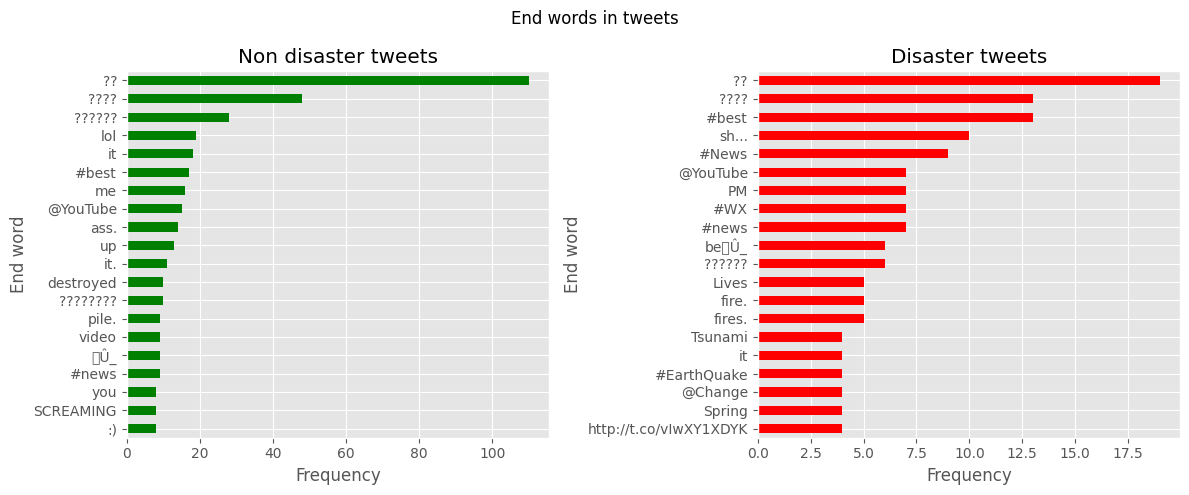

In [38]:

plt.figure(figsize=(12,5))

# Non disaster tweets
plt.subplot(1,2,1)
top_end_words_0.sort_values().plot(kind='barh', color='green')
plt.title("Non disaster tweets")
plt.xlabel("Frequency")
plt.ylabel("End word")

# Disaster tweets
plt.subplot(1,2,2)
top_end_words_1.sort_values().plot(kind='barh', color='red')
plt.title("Disaster tweets")
plt.xlabel("Frequency")
plt.ylabel("End word")

plt.suptitle("End words in tweets")

plt.tight_layout()
plt.show()

### **2.6 Number of urls per Tweet**


In [35]:
def number_urls(tweet):
    return tweet.count('http') + tweet.count('https') + tweet.count('www')


In [ ]:
X_train['num_urls'] = X_train['text'].apply(number_urls)
tweet_urls_0 = X_train[X_train['target'] == 0]['num_urls']
tweet_urls_1 = X_train[X_train['target'] == 1]['num_urls']


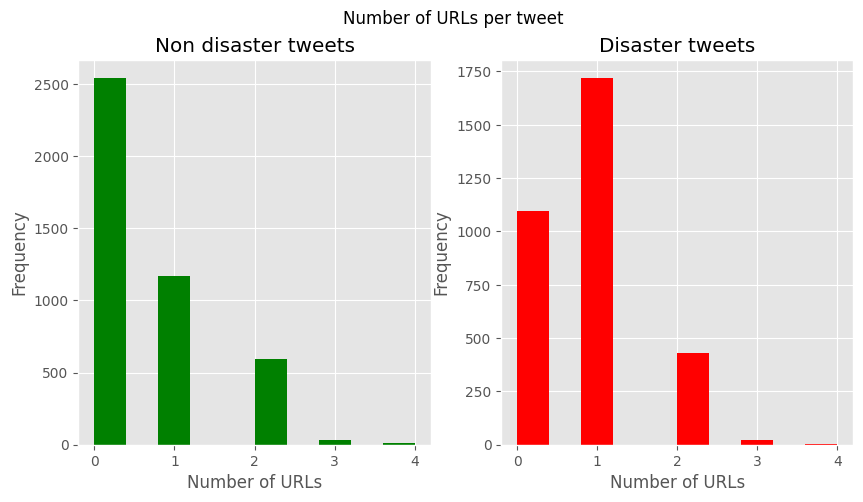

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.hist(tweet_urls_0, color='green')
ax1.set_title('Non disaster tweets')
ax1.set_xlabel('Number of URLs')
ax1.set_ylabel('Frequency')
ax2.hist(tweet_urls_1, color='red')
ax2.set_title('Disaster tweets')
ax2.set_xlabel('Number of URLs')
ax2.set_ylabel('Frequency')

fig.suptitle('Number of URLs per tweet')

plt.show()

### **2.7 Number of punctuation marks per Tweet**


In [71]:
def punctuation_count(tweet):
    count = 0
    for char in tweet:
        if char in string.punctuation:
            count += 1
    return count


def plot_punctuation(data, ax):

    punctuation_counts = data['text'].apply(punctuation_count)

    if data['target'].iloc[0] == 0:
        color = 'green'
        title = 'Non disaster tweets'
    else:
        color = 'red'
        title = 'Disaster tweets'

    ax.hist(punctuation_counts, color=color)
    ax.set_title(title)
    ax.set_xlabel('Number of punctuation marks')
    ax.set_ylabel('Frequency')


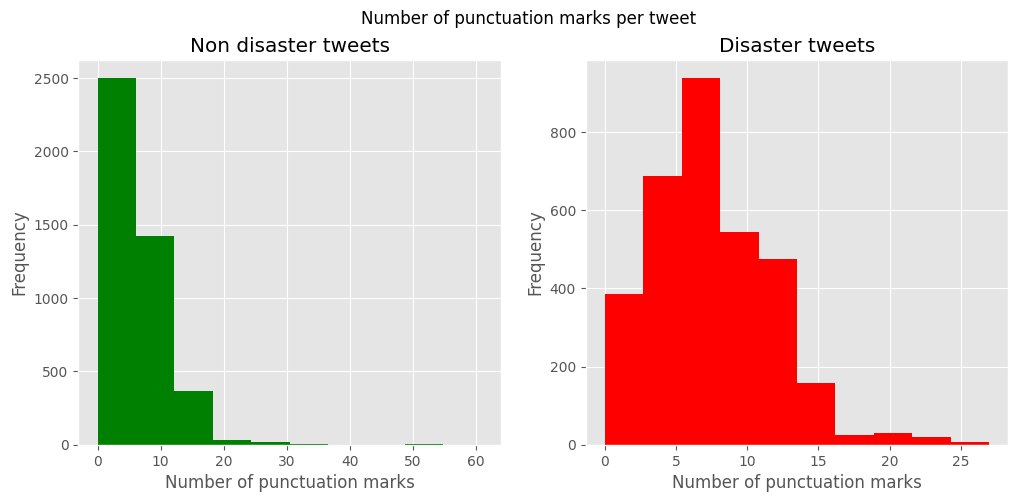

In [72]:
plt.figure(figsize=(12,5))

axis1 = plt.subplot(1,2,1)
plot_punctuation(X_train[X_train['target'] == 0], axis1)

axis2 = plt.subplot(1,2,2)
plot_punctuation(X_train[X_train['target'] == 1], axis2)

plt.suptitle("Number of punctuation marks per tweet")
plt.show()

### **2.8 Number of hashtags per Tweet**


In [ ]:
def hashtag_count(tweet):
    return len(re.findall(r"#\w+", tweet))

X_train['num_hashtags'] = X_train['text'].apply(hashtag_count)
tweet_hashtags_0 = X_train[X_train['target'] == 0]['num_hashtags']
tweet_hashtags_1 = X_train[X_train['target'] == 1]['num_hashtags']


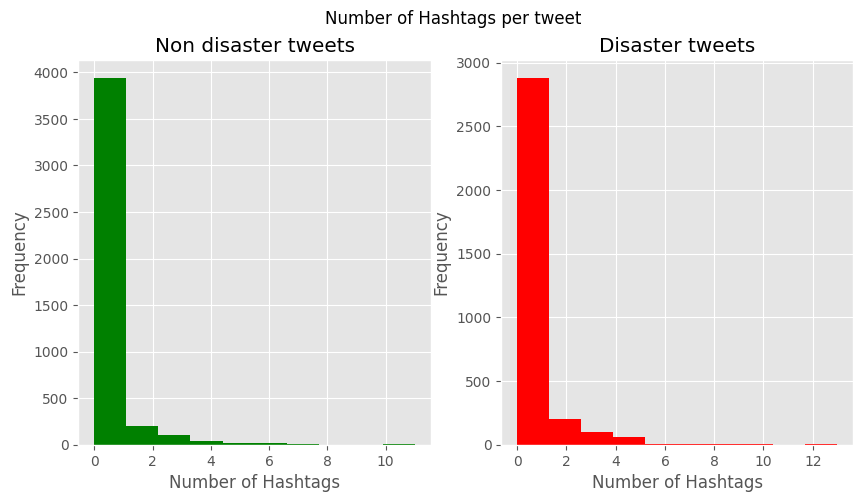

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.hist(tweet_hashtags_0, color='green')
ax1.set_title('Non disaster tweets')
ax1.set_xlabel('Number of Hashtags')
ax1.set_ylabel('Frequency')
ax2.hist(tweet_hashtags_1, color='red')
ax2.set_title('Disaster tweets')
ax2.set_xlabel('Number of Hashtags')
ax2.set_ylabel('Frequency')

fig.suptitle('Number of Hashtags per tweet')

plt.show()

### **2.9 Number of @'s per tweet**

In [75]:
def mentions_count(tweet):
    return len(re.findall(r"@(\w+)", tweet))

X_train['num_mentions'] = X_train['text'].apply(mentions_count)
tweet_mentions_0 = X_train[X_train['target'] == 0]['num_mentions']
tweet_mentions_1 = X_train[X_train['target'] == 1]['num_mentions']

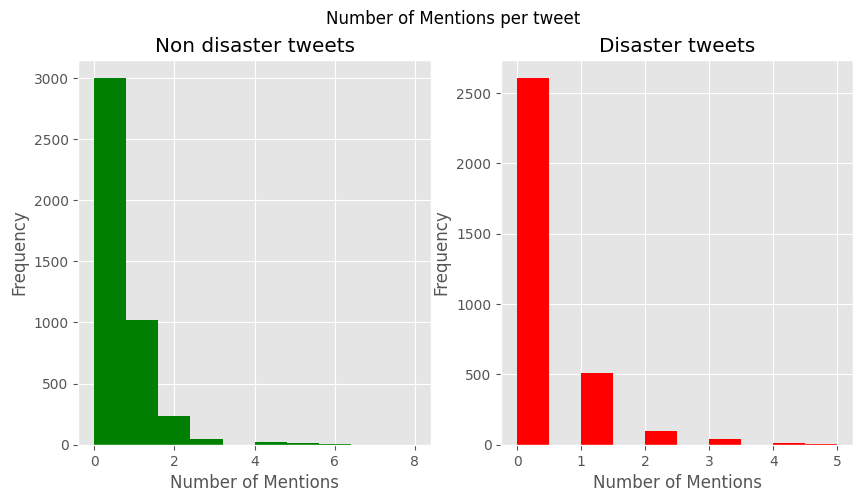

In [76]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.hist(tweet_mentions_0, color='green')
ax1.set_title('Non disaster tweets')
ax1.set_xlabel('Number of Mentions')
ax1.set_ylabel('Frequency')
ax2.hist(tweet_mentions_1, color='red')
ax2.set_title('Disaster tweets')
ax2.set_xlabel('Number of Mentions')
ax2.set_ylabel('Frequency')

fig.suptitle('Number of Mentions per tweet')

plt.show()

### **2.10 Most used stopwords**

These words do not have a meaning by themselves, but modify or accompany others, this group usually consists of articles, pronouns, prepositions, adverbs and even some verbs.

In natural language data processing they are filtered before or after the process itself, they are not considered because they have no meaning, in the case of search engines such as Google they are not considered at the time of positioning, but they are considered at the time of displaying search results.

In [77]:
from nltk.corpus import stopwords
import nltk

nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]

True

In [78]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [81]:
def plot_stopwords(label):
    tweets_stopwords = {}
    for words in X_train[X_train['target'] == label]['text'].str.split():
        sw = list(set(words).intersection(stopwords.words('english')))
        for w in sw:
            if w in tweets_stopwords.keys():
                tweets_stopwords[w] += 1
            else:
                tweets_stopwords[w] = 1

    top = sorted(tweets_stopwords.items(), key=lambda x:x[1],reverse=True)[:10]
    plt.bar(*zip(*top))
    plt.show()

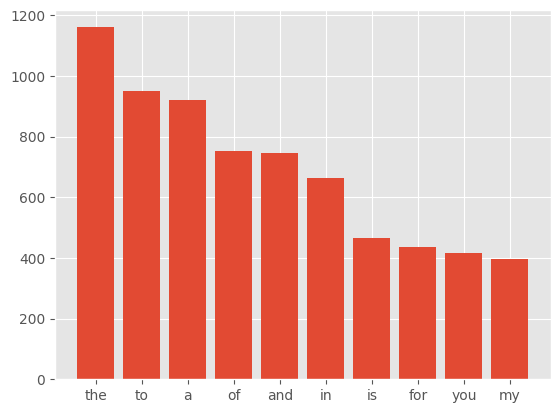

In [82]:
plot_stopwords(0)

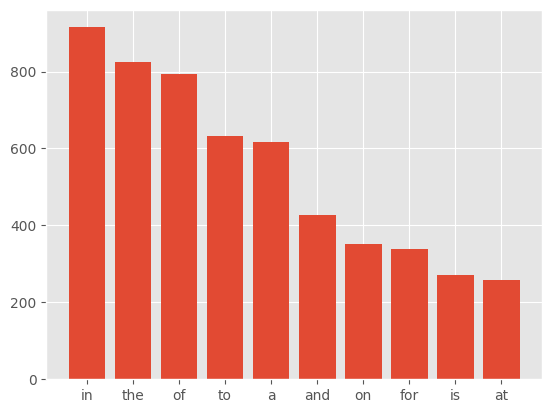

In [83]:
plot_stopwords(1)

### **2.11 Ngram analysis**

In [84]:
from sklearn.feature_extraction.text import CountVectorizer

In [103]:
def word_freq(label, data):
    cv = CountVectorizer(ngram_range=(2, 2))
    sum_words = cv.fit_transform(data[data['target'] == label]['text']).sum(axis=0)
    words = []
    freq = []
    for word, idx in cv.vocabulary_.items():
        words.append(word)
        freq.append(sum_words[0, idx])
    return words, freq


words_0, freq_0 = word_freq(0, X_train)
words_1, freq_1 = word_freq(1, X_train)


In [104]:
pairs_0 = sorted(zip(words_0, freq_0), key=lambda x: x[1], reverse=True)[:20]
pairs_1 = sorted(zip(words_1, freq_1), key=lambda x: x[1], reverse=True)[:20]

words_0, freq_0 = zip(*pairs_0)
words_1, freq_1 = zip(*pairs_1)

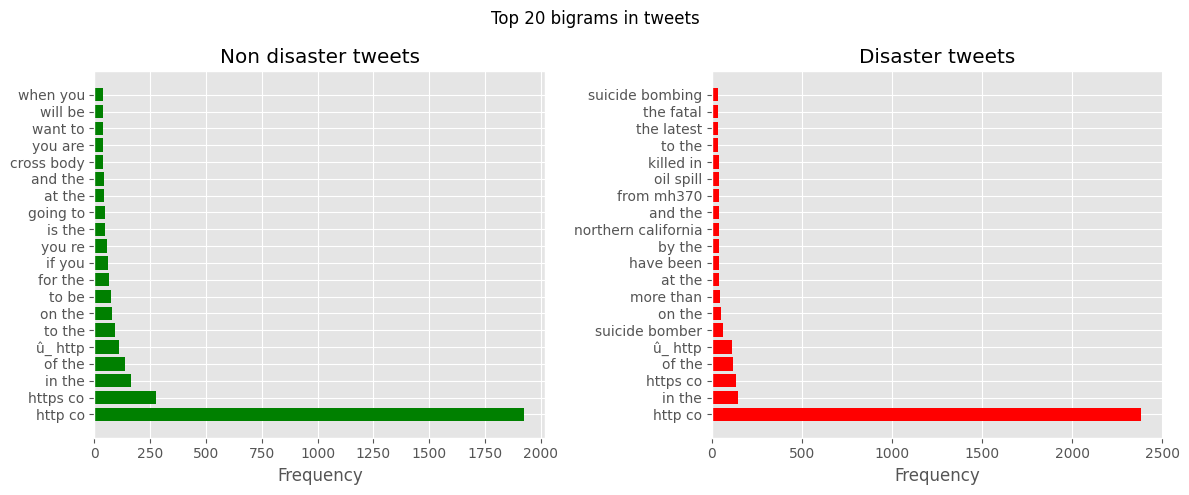

In [105]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.barh(words_0[:20], freq_0[:20], color='green')
ax1.set_title('Non disaster tweets')
ax1.set_xlabel('Frequency')

ax2.barh(words_1[:20], freq_1[:20], color='red')
ax2.set_title('Disaster tweets')
ax2.set_xlabel('Frequency')

fig.suptitle('Top 20 bigrams in tweets')

plt.tight_layout()
plt.show()

## **3. Text content analysis**

### 3.1 **Wordcloud** 

In [2]:
import sys
!{sys.executable} -m pip install wordcloud

  Using cached wordcloud-1.9.6-cp310-cp310-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.6-cp310-cp310-win_amd64.whl (306 kB)


In [3]:
from wordcloud import WordCloud

In [10]:
disaster_text = " ".join(X_train[X_train['target']==1]['text'])
nondisaster_text = " ".join(X_train[X_train['target']==0]['text'])

In [11]:
wc_disaster = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(disaster_text)

wc_nondisaster = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(nondisaster_text)

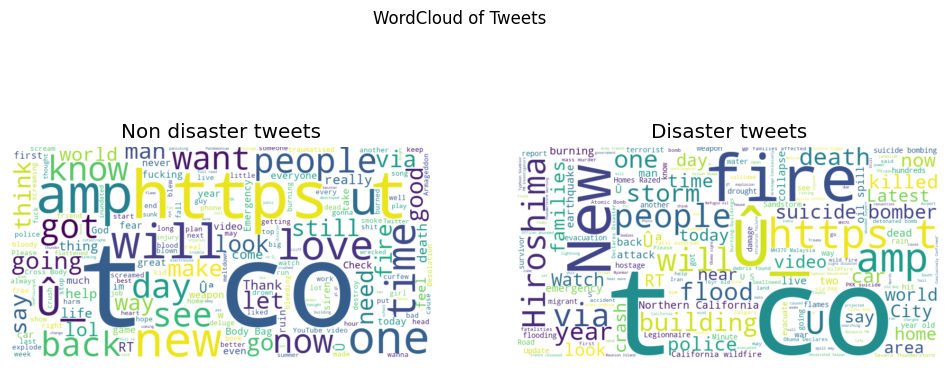

In [12]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

ax1.imshow(wc_nondisaster, interpolation='bilinear')
ax1.axis('off')
ax1.set_title("Non disaster tweets")

ax2.imshow(wc_disaster, interpolation='bilinear')
ax2.axis('off')
ax2.set_title("Disaster tweets")

plt.suptitle("WordCloud of Tweets")
plt.show()

### 3.2 **Top 20 Most Frequent Words**

In [14]:
from collections import Counter

In [25]:
url_regex = r'http\S+'

def simple_tokenize(tweet):
    text = re.sub(url_regex, '', tweet)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    tokens = text.lower().split()
    return tokens

def get_top_tokens(tweets, n=20):
    '''Get top n tokens from a list of tweets
    '''
    all_tokens = []
    for tweet in tweets:
        all_tokens.extend(simple_tokenize(tweet))
    token_counts = Counter(all_tokens)
    word, freq = zip(*token_counts.most_common(n))
    return word, freq

In [26]:
words_0, freq_0 = get_top_tokens(X_train[X_train['target']==0]['text'], 20)
words_1, freq_1 = get_top_tokens(X_train[X_train['target']==1]['text'], 20)

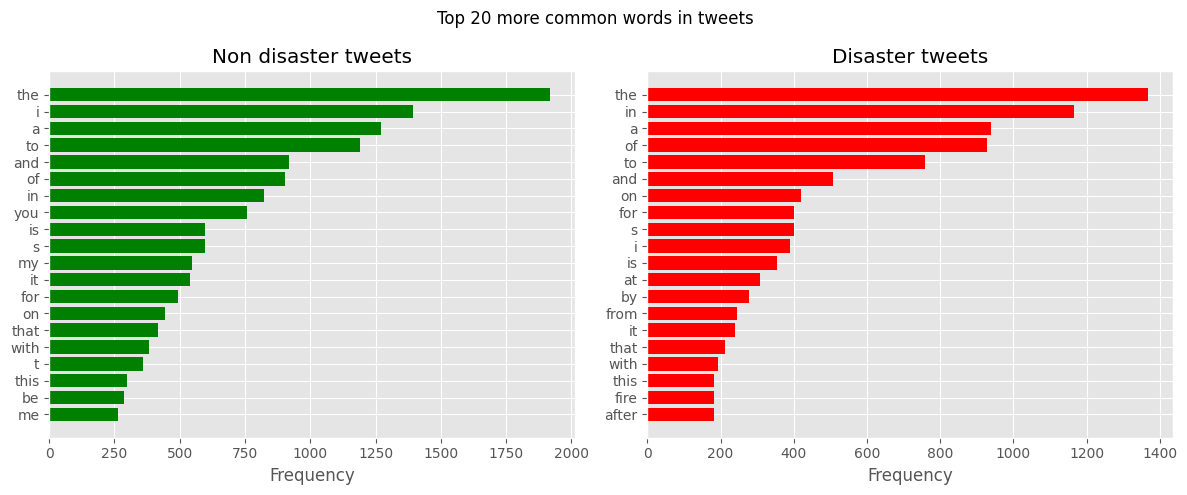

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.barh(words_0[:20], freq_0[:20], color='green')
ax1.set_title('Non disaster tweets')
ax1.set_xlabel('Frequency')
ax1.invert_yaxis()
ax2.barh(words_1[:20], freq_1[:20], color='red')
ax2.set_title('Disaster tweets')
ax2.set_xlabel('Frequency')
ax2.invert_yaxis()

fig.suptitle('Top 20 more common words in tweets')

plt.tight_layout()
plt.show()

### 3.3 **Word co-occurrence graph**

In [30]:
!{sys.executable} -m pip install networkx

  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)


In [31]:
import networkx as nx
from itertools import combinations
from collections import Counter

In [35]:
def get_cooccurrence_pairs(tweets):
    
    pairs = []
    
    for tweet in tweets:
        tokens = simple_tokenize(tweet)
        tokens = list(set(tokens))
        
        pairs.extend(combinations(tokens, 2))
    
    return Counter(pairs)

In [38]:
co_counts = get_cooccurrence_pairs(X_train[X_train['target']==1]['text'])
top_pairs = co_counts.most_common(50)
G = nx.Graph()

for (w1, w2), weight in top_pairs:
    G.add_edge(w1, w2, weight=weight)

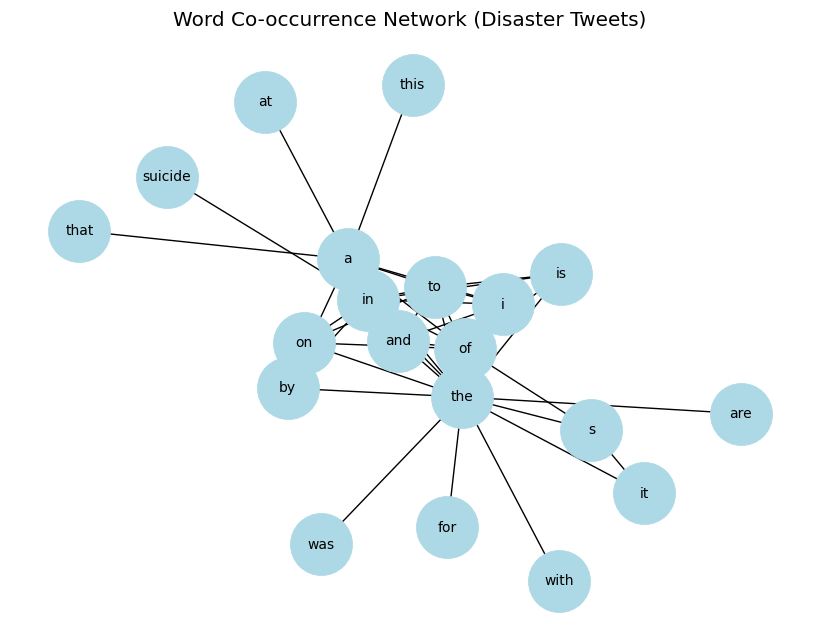

In [39]:
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, k=0.5)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='lightblue',
    node_size=2000,
    font_size=10
)

plt.title("Word Co-occurrence Network (Disaster Tweets)")
plt.show()

In [42]:
def plot_cooccurrence_network(label, number_pairs=50):
    co_counts = get_cooccurrence_pairs(X_train[X_train['target']==label]['text'])
    top_pairs = co_counts.most_common(number_pairs)
    G = nx.Graph()

    for (w1, w2), weight in top_pairs:
        G.add_edge(w1, w2, weight=weight)
    
    if label == 0:
        color = 'lightgreen'
        title = 'Non disaster tweets'
    else:
        color = 'lightcoral'
        title = 'Disaster tweets'
    plt.figure(figsize=(8,6))

    pos = nx.spring_layout(G, k=0.5)

    nx.draw(
    G,
    pos,
    with_labels=True,
    node_color= color,
    node_size=2000,
    font_size=10
    )

    plt.title(f"Word Co-occurrence Network ({title})")
    plt.show()

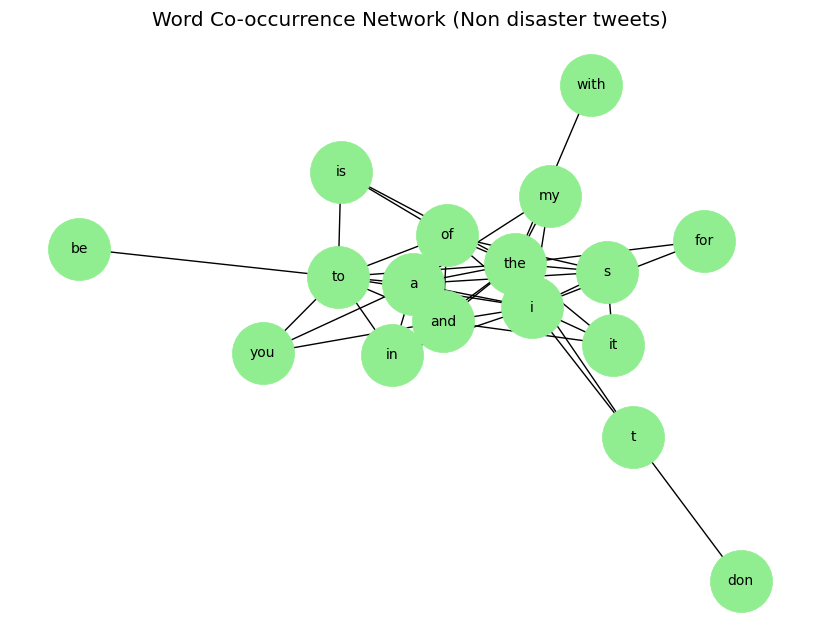

In [43]:
plot_cooccurrence_network(0)

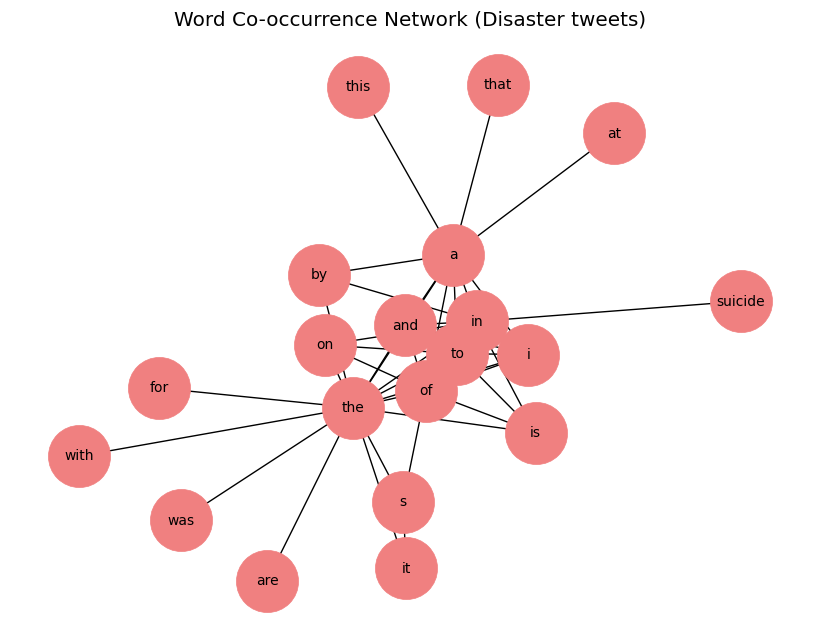

In [45]:
plot_cooccurrence_network(1)

## 3. Data set cleaning

In [ ]:
import re # to define regular expressions

In [ ]:
def remove_url(text):
    url = re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'', text)

In [ ]:
remove_url("Esto es una prueba: http://localhost:8888/notebooks/Desktop/Workspace/Deep%20Neural%20Networks%20Course/11.%20Consideraciones%20de%20un%20proyecto%20de%20Deep%20Learning/code/Disaster%20Tweets.ipynb")

'Esto es una prueba: '

In [ ]:
from html.parser import HTMLParser

class HTMLStripper(HTMLParser):
    def __init__(self):
        self.reset()
        self.strict = False
        self.convert_charrefs = True
        self.fed = []

    def handle_data(self, d):
        self.fed.append(d)

    def get_data(self):
        return ''.join(self.fed)

def remove_html(text):
    s = HTMLStripper()
    s.feed(text)
    return s.get_data()

In [ ]:
remove_html('<tr><td align="left"><a href="../../issues/51/16.html#article">Phrack World News</a></td>')

'Phrack World News'

In [ ]:
def remove_emoji(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

In [ ]:
remove_emoji("Omg another Earthquake 😔😔")

'Omg another Earthquake '

In [ ]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

In [ ]:
remove_punctuation("hello # how are you")

'hello  how are you'

In [ ]:
# We apply our dataset cleaning functions
X_train_prep = X_train.copy()

X_train_prep['text'] = X_train['text'].apply(remove_url)
X_train_prep['text'] = X_train['text'].apply(remove_html)
X_train_prep['text'] = X_train['text'].apply(remove_emoji)
X_train_prep['text'] = X_train['text'].apply(remove_punctuation)

In [ ]:
# We apply our dataset cleaning functions
X_test_prep = X_test.copy()

X_test_prep['text'] = X_test['text'].apply(remove_url)
X_test_prep['text'] = X_test['text'].apply(remove_html)
X_test_prep['text'] = X_test['text'].apply(remove_emoji)
X_test_prep['text'] = X_test['text'].apply(remove_punctuation)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(ngram_range=(2, 2))
sum_words = cv.fit_transform(X_train_prep['text']).sum(axis=0)

# We calculate
words_freq = [(word, sum_words[0, idx]) for word, idx in cv.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)[:20]

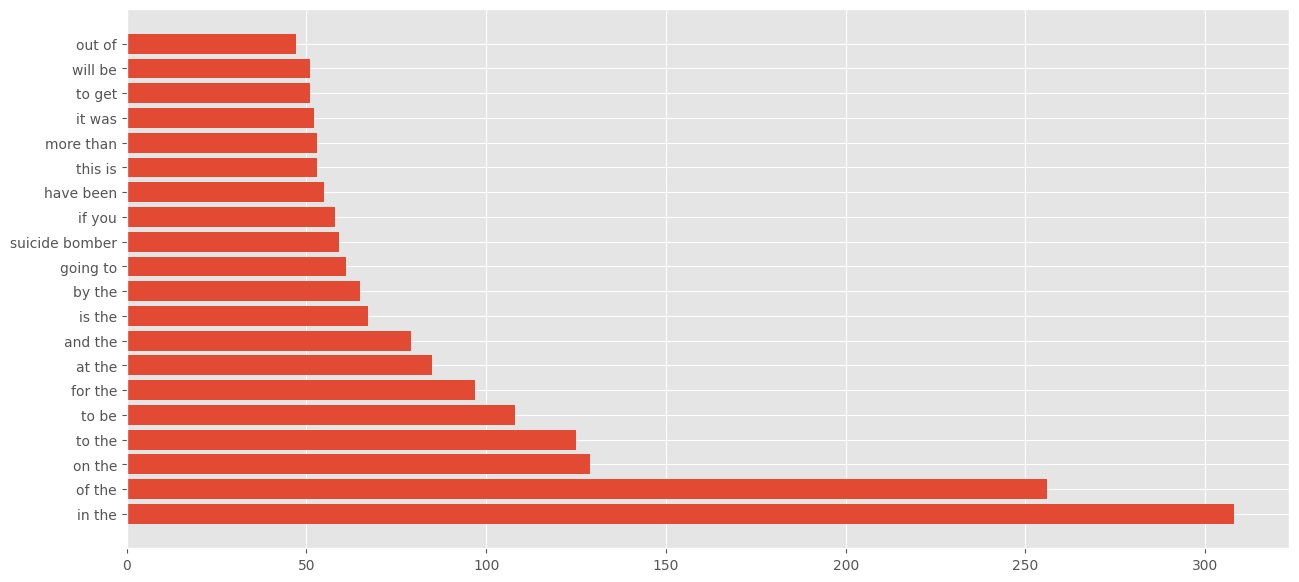

In [ ]:
plt.figure(figsize=(15, 7))
plt.barh(*zip(*words_freq))
plt.show()

## 4. Vectorization of the data set

In [ ]:
Y_train = X_train_prep['target']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer #based in frequencies

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train_prep['text'])

In [ ]:
X_train = X_train.toarray()

In [ ]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
X_test = vectorizer.transform(X_test_prep['text'])
X_test = X_test.toarray()

## 5. Division of the data set

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.15)

In [ ]:
print("Length of training subset: ", len(X_train))
print("Length of validation subset: ", len(X_val))
print("Length of test subset: ", len(X_test))

Length of training subset:  6471
Length of validation subset:  1142
Length of test subset:  3263


## 6. Model construction

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()

model.add(layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
#model.add(layers.Dropout(0.4))
model.add(layers.Dense(16, activation='relu'))
#model.add(layers.Dropout(0.4))
model.add(layers.Dense(1, activation='sigmoid'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision']
)

In [ ]:
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=1024,
    validation_data=(X_val, Y_val))

Epoch 1/10
7/7 [==============================] - 2s 207ms/step - loss: 0.6917 - accuracy: 0.5681 - precision: 0.4725 - val_loss: 0.6898 - val_accuracy: 0.5490 - val_precision: 1.0000
Epoch 2/10
7/7 [==============================] - 1s 150ms/step - loss: 0.6844 - accuracy: 0.5928 - precision: 1.0000 - val_loss: 0.6843 - val_accuracy: 0.5736 - val_precision: 0.9744
Epoch 3/10
7/7 [==============================] - 1s 139ms/step - loss: 0.6739 - accuracy: 0.6475 - precision: 1.0000 - val_loss: 0.6771 - val_accuracy: 0.6156 - val_precision: 0.9775
Epoch 4/10
7/7 [==============================] - 1s 143ms/step - loss: 0.6604 - accuracy: 0.7268 - precision: 0.9980 - val_loss: 0.6684 - val_accuracy: 0.6681 - val_precision: 0.9801
Epoch 5/10
7/7 [==============================] - 1s 152ms/step - loss: 0.6440 - accuracy: 0.7897 - precision: 0.9943 - val_loss: 0.6581 - val_accuracy: 0.7093 - val_precision: 0.9706
Epoch 6/10
7/7 [==============================] - 1s 144ms/step - loss: 0.6243 -

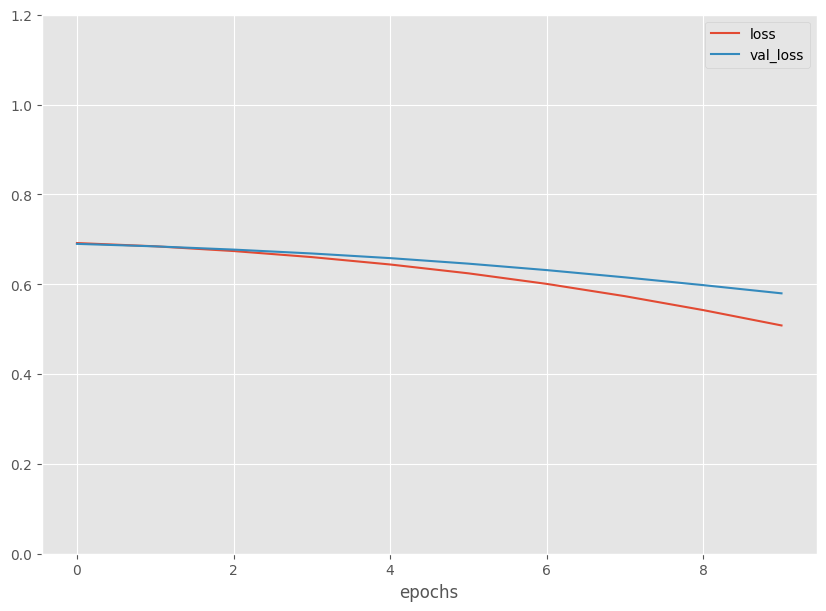

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(10, 7))
plt.grid(True)
plt.gca().set_ylim(0, 1.2)
plt.xlabel("epochs")
plt.show()

## 7. Model evaluation

In [ ]:
Y_pred = model.predict(X_test).round(0)
Y_pred

102/102 [==============================] - 0s 3ms/step


array([[1.],
       [0.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]], dtype=float32)

In [ ]:
for i in range(30):
    print("{} - {}".format(X_test_prep['text'][i], Y_pred[i]))

Just happened a terrible car crash - [1.]
Heard about earthquake is different cities stay safe everyone - [0.]
there is a forest fire at spot pond geese are fleeing across the street I cannot save them all - [1.]
Apocalypse lighting Spokane wildfires - [1.]
Typhoon Soudelor kills 28 in China and Taiwan - [1.]
Were shakingIts an earthquake - [1.]
Theyd probably still show more life than Arsenal did yesterday eh EH - [0.]
Hey How are you - [0.]
What a nice hat - [0.]
Fuck off - [0.]
No I dont like cold - [0.]
NOOOOOOOOO Dont do that - [0.]
No dont tell me that - [0.]
What if - [0.]
Awesome - [0.]
Birmingham Wholesale Market is ablaze BBC News  Fire breaks out at Birminghams Wholesale Market httptcoirWqCEZWEU - [0.]
sunkxssedharry will you wear shorts for race ablaze  - [0.]
PreviouslyOnDoyinTv Toke MakinwaÛªs marriage crisis sets Nigerian Twitter ablaze httptcoCMghxBa2XI - [1.]
Check these out httptcorOI2NSmEJJ httptco3Tj8ZjiN21 httptcoYDUiXEfIpE httptcoLxTjc87KLS nsfw - [0.]
PSA IÛªm 